2026-04-21 13:12:01.102559: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 13:12:01.126268: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-21 13:12:01.126292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-21 13:12:01.127049: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-21 13:12:01.131281: I tensorflow/core/platform/cpu_feature_guar

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-04-21 13:12:02.404793: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-21 13:12:02.413613: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-21 13:12:02.418632: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

[[0.02504599]]
[0.]
0.025045991 0.0


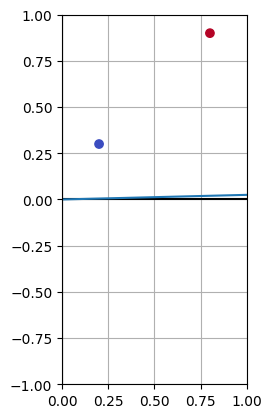

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
# Data 세팅
x_train = np.array([[0.2],[0.8]])
y_train = np.array([[0.3],[0.9]])

# Model 구성
# Input([1]) : x가 1개 (입력), dense(1,) : y가 1개 (출력)
input_layer = Input([1])
output_layer = Dense(1, activation=None)(input_layer)
model = Model(input_layer, output_layer)

# 표 요약
model.summary()
# output_layer 선택
layer = model.layers[1]
# 출력 결과에서 가중치 가져오기
weights = layer.get_weights()

# w (기울기)
w_start = weights[0][0][0]
# b (편향)
b_start = weights[1][0]

print(weights[0])
print(weights[1])
print(w_start, b_start)

from matplotlib import pyplot as plt
from matplotlib import cm

w, b = w_start, b_start
# 그래프전체영역, 그래프 축 생성
fig, ax = plt.subplots()
# x축 y축 스케일 비율 1:1
ax.set_aspect('equal')
# 그래프에 격자무늬 표시, 주요/보조눈금 모두에 표시
ax.grid(True, which='both')
# y=0지점에 수평선 긋기, 검은색
ax.axhline(y=0, color='k')
# x=0지점에 수직선 긋기
ax.axvline(x=0, color='k')
# x축은 0~1, y축은 -1~1 까지만 범위 지정
ax.axis([0,1,-1,1])
# 데이터를 점으로 찍기, y값에 따라 색깔 다르게, 파란색~빨간색 사용
ax.scatter(x_train,y_train,c=y_train,cmap=cm.coolwarm)
# 0~1을 51개 간격으로 쪼개서 직선 매끄럽게 그림
x = np.linspace(0,1,51)
# y값 계산
y = w*x+b
# x, y좌표들을 연결해서 선그래프를 그림
ax.plot(x,y)
plt.show()
#plt.savefig('result.png')